<a href="https://colab.research.google.com/github/emilyrgarman/ml3finalproject_triage/blob/main/MODEL_BUILDING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Building

* Tabular data - ANN, XGBoost
* Text data - RNN, ClinicalBERT
* Fusion techniques: late fusion, early fusion (MLP from scratch)


## Preprocessing

* Loading in Kaggle data
* Removing severity adjectives and descriptions that indicate triage level
* Augmenting data to introduce noise
* Removing duplicate text rows
* Train/val/test split

In [1]:
# Load Data
from pathlib import Path
if (Path('/content').is_dir()) :
    # Running on Google Colab   
    ! git clone https://github.com/emilyrgarman/ml3finalproject_triage.git
    datadir = Path('/content/ml3finalproject_triage')
else:
    # Running locally from existing git clone
    datadir = Path('.')


fatal: destination path 'ml3finalproject_triage' already exists and is not an empty directory.


In [2]:
# Import libraries
from typing import Union
import pandas as pd
import numpy as np
import random
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import platform
import torch

SEEDS = [42, 47, 88, 101, 24601]
SEED = SEEDS[0]
random.seed(SEEDS[1])
np.random.seed(SEEDS[2])
torch.manual_seed(SEEDS[3])
torch.cuda.manual_seed(SEEDS[4])
torch.backends.cudnn.deterministic = True

In [3]:
# Determine GPU
X86=1
ARM64=2

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    gpu_count = 1
    if platform.machine == 'arm64':
        onLaptop = ARM64
    else:
        onLaptop = X86

elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    gpu_count = torch.cuda.device_count()
    onLaptop = False

else:
    DEVICE = torch.device("cpu")
    gpu_count = 0
    onLaptop = False

if __name__ == '__main__':
    print(f"Using device: {DEVICE}")
    if DEVICE.type == "mps":
        print(f"MPS is available! Current device: {torch.backends.mps.get_name()}")
        print(f"MPS CPU is {'x86' if onLaptop == X86 else 'ARM64'}")
    elif DEVICE.type == "cuda":
        print(f"CUDA is available! {torch.cuda.device_count()} devices, current device: {torch.cuda.get_device_name()}")
        print(f"GPU count = {gpu_count}")


Using device: cuda
CUDA is available! 1 devices, current device: Tesla T4
GPU count = 1


In [4]:
tab_data = pd.read_csv(datadir / 'train.csv')
complaints = pd.read_csv(datadir / 'chief_complaints.csv')
history = pd.read_csv(datadir / 'patient_history.csv')

In [5]:
SEVERITY_WORDS = ['mild', 'moderate', 'severe',
                  'critical', 'minor', 'major', 'actively',
                  'intermittent', 'in known patient']
def clean_complaint(x):
    x = re.split(r'[,\uff0c]', x)[0]
    return re.sub('|'.join(SEVERITY_WORDS), '', x, flags=re.IGNORECASE).strip()

complaints['cc_stripped'] = complaints['chief_complaint_raw'].apply(clean_complaint)
complaints = complaints.drop_duplicates(subset=['cc_stripped'])

In [6]:
df = tab_data.merge(complaints[['patient_id', 'cc_stripped']], on='patient_id', how='inner')
df = df.merge(history, on='patient_id', how='inner')

In [7]:
# ── Columns ────────────────────────────────────────────────
NUMERIC_COLS = ['age', 'num_active_medications', 'num_comorbidities',
                'systolic_bp', 'diastolic_bp', 'heart_rate',
                'respiratory_rate', 'temperature_c', 'spo2',
                'gcs_total', 'pain_score', 'bmi',
                'num_prior_ed_visits_12m', 'num_prior_admissions_12m']
CATEG_COLS   = ['arrival_mode', 'sex', 'transport_origin',
                'pain_location', 'mental_status_triage']
DUMMY_COLS   = ['hx_hypertension', 'hx_diabetes_type2', 'hx_diabetes_type1',
                'hx_asthma', 'hx_copd', 'hx_heart_failure', 'hx_atrial_fibrillation',
                'hx_ckd', 'hx_liver_disease', 'hx_malignancy', 'hx_obesity',
                'hx_depression', 'hx_anxiety', 'hx_dementia', 'hx_epilepsy',
                'hx_hypothyroidism', 'hx_hyperthyroidism', 'hx_hiv', 'hx_coagulopathy',
                'hx_immunosuppressed', 'hx_pregnant', 'hx_substance_use_disorder',
                'hx_coronary_artery_disease', 'hx_stroke_prior',
                'hx_peripheral_vascular_disease']

TARGET_COL = 'triage_acuity'
TEXT_COL   = 'cc_stripped'
TABULAR_COLS = NUMERIC_COLS + CATEG_COLS + DUMMY_COLS

# ── Encode categorical columns ───────────────────────────
for col in CATEG_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# ── Tabular preprocessing ────────────────────────────────
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_tab = scaler.fit_transform(imputer.fit_transform(df[TABULAR_COLS]))

# ── Labels ───────────────────────────────────────────────
y = df[TARGET_COL].values - 1  # shift 1–5 → 0–4 for CrossEntropyLoss

# ── Split into train, val, test ──────────────────────────
# stratify ensures class distribution is preserved
X_temp, X_test, y_temp, y_test, texts_temp, texts_test = train_test_split(
    X_tab, y, df[TEXT_COL].fillna('').values,
    test_size=0.1, random_state=42, stratify=y
)

X_tr, X_val, y_tr, y_val, texts_tr, texts_val = train_test_split(
    X_temp, y_temp, texts_temp,
    test_size=0.2, random_state=42, stratify=y_temp
)

# ── Verification ─────────────────────────────────────────
overlap_train_val = set(texts_tr) & set(texts_val)
overlap_train_test = set(texts_tr) & set(texts_test)
overlap_val_test = set(texts_val) & set(texts_test)

print(f"Train: {len(y_tr)} | Val: {len(y_val)} | Test: {len(y_test)}")
print(f"Overlap Train/Val: {len(overlap_train_val)}")
print(f"Overlap Train/Test: {len(overlap_train_test)}")
print(f"Overlap Val/Test: {len(overlap_val_test)}")

Train: 1414 | Val: 354 | Test: 197
Overlap Train/Val: 0
Overlap Train/Test: 0
Overlap Val/Test: 0


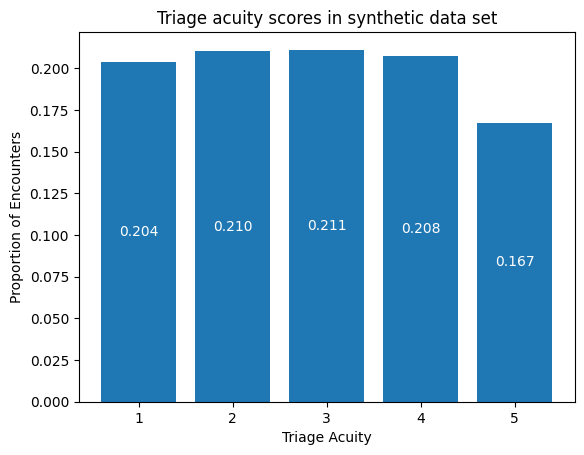

In [8]:
# %%
triage_acuity_ratios = df['triage_acuity'].value_counts(normalize=True).sort_index()

# %%
# plot bar chart on acuities
bars = plt.bar(triage_acuity_ratios.index, triage_acuity_ratios.values)
plt.title('Triage acuity scores in synthetic data set')
plt.xlabel('Triage Acuity')
plt.ylabel('Proportion of Encounters')
plt.bar_label(bars, fmt='%.3f', label_type='center', color="white")
plt.show()


In [9]:
# Real World Weight Crosentropy Loss Function
# Based on the paper by Ho, Y., & Wookey, S. (2020). 
# The Real-World-Weight Cross-Entropy Loss Function: Modeling the Costs of Mislabeling. 
# IEEE Access, 8, 4806–4813. https://doi.org/10.1109/ACCESS.2019.2962617
# and the authors' implementation at
# https://github.com/yaoshiang/The-Real-World-Weight-Crossentropy-Loss-Function/
#
# Original Copyright: 
# Copyright (C) 2019 Yaoshiang Ho
#
# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.
#
# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
# GNU General Public License for more details.
#
# Contact author for exceptions.
#
# You should have received a copy of the GNU General Public License
# along with this program.  If not, see <https://www.gnu.org/licenses/>.

def create_rww_categorical_crossentropy(k, 
                                        loss_type, 
                                        fn_weights:Union[np.ndarray, None]=None, 
                                        fp_weights:Union[np.ndarray, None]=None, 
                                        return_weights=False,
                                        device="cpu"
                                        ):
  """Real-World-Weighted crossentropy between an output tensor and a target tensor.
  
  The loss_types other than rww_categorical_crossentropy reimplement existing 
  functions in Keras but are not as well optimized. 
  These loss_types are usable directly, but, are more useful when calling 
  return_weights=True, which then returns fn and fp weights matrixes of size (k,k). 
  Editing those to reflect real world costs, then passing them back into 
  create_rww_crossentropy with loss_type "rww_crossentropy" is the recommended approach. 

  Example Usage: 

  Suppose you have three classes: cat, dog, and other.
  
  Cat is one-hot encoded as [1,0,0], dog as [0,1,0], other as [0,0,1]
  
  The the following code increases the incremental penalty of 
  mislabeling a true target 0 (cat) with a false label 1 (dog) at a cost of 99, 
  versus the default of zero. Note that the existing fn_weights also has a 
  default cost of 1 for missing the true target of 1, for a total cost of 
  100 versus the default cost of 1. 
  
  fn_weights, fp_weights = create_rww_categorical_crossentropy(10, "categorical_crossentropy", return_weights=True)
  fp_weights[0, 1] = 99
  loss = create_rww_categorical_crossentropy(10, "rww_crossentropy", fn_weights, fp_weights)

... 
  
  The fn and fp weights are easy to reason about. 
  
  fn_weights is [x1, __, __]
                [__, x2, __]
                [__, __, x3]
 
  x1 represents the scale of the cost for a fn for cat, x2 for dog, and x3 for other.
  
  This is calculated as fn_weight * log(y_pred). 
  
  In the case of loss_type=categorical_crossentropy, 
  x1, x2, and x3 all equal the value one. 
  All elements not on the main axis must equal zero. 
  
  Note that fn_weights could have been represented as a vector, 
  not a matrix, however, we use a matrix to keep symmetry with 
  fp_weights, and, to prepare for 
  multi-label classification. 
    
  ...

  fp_weights is concerned with the costs of the fps from the other classes. 

  fp_weights of [__, x1, x2]
                [x3, __, x4]
                [x5, x6, __]
 
  x1 represents the cost of predicting 1 for dog, when it should be 0 for cat. 
  x2 represents predicting 2 for other, when the target is 0 for cat. 
  x3 represents predicing 0 for cat, when the target is 1 for dog.
  etc. 
  
  Args:
    * k: 2 or more for number of categories, including "other". 
    * loss_type: "categorical_crossentropy" to initialize to 
      standard softmax_crossentropy behavior, 
      or "weighted_categorical_crossentropy" for standard behavior, or, 
      or "rww_crossentropy" for full weight matrix of all possible fn/fp combinations. 
    * fn_weights: a numpy array of shape (k,k). The main diagonal can
      contain non-zero values; all other values must be zero. 
    * fp_weights: a numpy array of shape (k,k) to define specific combinations 
      of false positive. The main diag should be zeros. 
    * return_weights: If False (default), returns cost function. If True, 
      returns fn and fp weights as np.array. 
Returns:
    * retval: Loss function for use Keras.model.fit, or if return_weights
      arg is True, the fn_weights and fp_weights matrixes. 
  """

  assert return_weights or (fn_weights is not None and fp_weights is not None)

  full_fn_weights = None
  full_fp_weights = None

  anti_eye = np.ones((k,k), dtype=np.float32) - np.eye(k, dtype=np.float32)
    
  if (return_weights or loss_type=="categorical_crossentropy"):
    full_fn_weights = np.identity((k), dtype=np.float32)
    full_fp_weights = np.zeros((k, k), dtype=np.float32) # Softmax crossentropy ignores fp.

  elif(loss_type=="weighted_categorical_crossentropy"):
    assert fn_weights is not None
    full_fn_weights = np.eye(k, dtype=np.float32) * fn_weights
    full_fp_weights = np.zeros((k, k), dtype=np.float32) # softmax crossentropy ignores fp
    
  elif(loss_type=="rww_crossentropy"):
    assert fn_weights is not None
    assert fp_weights is not None
    assert not np.count_nonzero(fn_weights * anti_eye)
    assert not np.count_nonzero(fp_weights * np.eye(k, dtype=np.float32))

    full_fn_weights = fn_weights
    # Novel piece: allow any combination of fp.
    full_fp_weights = fp_weights
    
  else:
    raise Exception("unknown loss_type: " + str(loss_type))
  
  # (k,k), always sparse along main diag. 
  fn_wt = torch.as_tensor(full_fn_weights).to(device) 
  # (k,k), always dense except main diag. 
  fp_wt = torch.as_tensor(full_fp_weights).to(device)

  # eps = torch.finfo(fn_wt.dtype).eps

  def loss_function(output, target):
    # print(f'output.shape: {output.shape}, target.shape: {target.shape}')
    eps = torch.finfo(output.dtype).eps
    output = torch.clamp(output, eps, 1 - eps) 
    
    # Convert class index to one-hot: (m, 1) -> (m, k)
    target_1hot = torch.zeros_like(output)
    target_1hot.scatter_(1, target.unsqueeze(1), 1.0)

    logs = torch.log(output) # shape (m, k), dense. 1 is good. 
    logs_1_sub = torch.log(1-output) # shape (m, k), dense. 0 is good. 

    m_full_fn_weights = torch.matmul(target_1hot, fn_wt) # (m,k) . (k, k)
    m_full_fp_weights = torch.matmul(target_1hot, fp_wt) # (m,k) . (k, k)

    return - torch.mean(m_full_fn_weights * logs + 
                    m_full_fp_weights * logs_1_sub)
  
  if (return_weights):
    return full_fn_weights, full_fp_weights
  else:
    return loss_function

In [10]:
# ── Configure Weighted Loss Function ───────────────────────────────
acquity_count = 5
fn_weights, fp_weights = create_rww_categorical_crossentropy(acquity_count, 
                            "categorical_crossentropy", return_weights=True)

immediate, emergent, urgent, semi, non = range(5)

# Emphasize false negative weights of high risk to health categories
fn_weights[immediate, immediate] = 5
fn_weights[emergent, emergent] = 5

# Slight false negative emphasis on less than urgent for cost savings
fn_weights[semi, semi] = 2
fn_weights[non, non] = 2

# Heavily weight false positives that increase risk to health (real > predicted)
# Slightly weight false positives that increase fiscal cost (real < predicted)
fp_weights [immediate, emergent] = 3
fp_weights [immediate, urgent] = 6
fp_weights [immediate, semi] = 10
fp_weights [immediate, non] = 10

fp_weights [emergent, immediate] = 2
fp_weights [emergent, urgent] = 3
fp_weights [emergent, semi] = 10
fp_weights [emergent, non] = 10

fp_weights [urgent, immediate] = 5
fp_weights [urgent, emergent] = 5
fp_weights [urgent, semi] = 3
fp_weights [urgent, non] = 4

fp_weights [semi, immediate] = 5
fp_weights [semi, emergent] = 5
fp_weights [semi, urgent] = 2
fp_weights [semi, non] = 3

fp_weights [non, immediate] = 5
fp_weights [non, emergent] = 5
fp_weights [non, urgent] = 3
fp_weights [non, semi] = 1

print(f'fp =\n{fp_weights}\nfn = \n{fn_weights}')


rww_loss_fn = create_rww_categorical_crossentropy(acquity_count, "rww_crossentropy", 
                                                  fn_weights, fp_weights,
                                                  device=DEVICE)


fp =
[[ 0.  3.  6. 10. 10.]
 [ 2.  0.  3. 10. 10.]
 [ 5.  5.  0.  3.  4.]
 [ 5.  5.  2.  0.  3.]
 [ 5.  5.  3.  1.  0.]]
fn = 
[[5. 0. 0. 0. 0.]
 [0. 5. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 2.]]


In [11]:
# ── Clinical abbreviations ─────────────────────────────────────────
ABBREV_MAP = {
    'with': 'w/',
    'without': 'w/o',
    'history of': 'hx of',
    'complaint of': 'c/o',
    'shortness of breath': 'SOB',
    'loss of consciousness': 'LOC',
    'atrial fibrillation': 'AF',
    'diabetic ketoacidosis': 'DKA',
    'urinary tract infection': 'UTI',
    'motor vehicle accident': 'MVA',
    'chest pain': 'CP',
    'blood pressure': 'BP',
    'heart rate': 'HR',
    'nausea and vomiting': 'N&V',
    'upper respiratory tract infection': 'URTI',
    'shortness of breath': 'SOB',
    'gastrointestinal': 'GI',
    'myocardial infarction': 'MI',
    'pulmonary embolism': 'PE',
    'deep vein thrombosis': 'DVT',
    'electrocardiogram': 'ECG',
    'fracture': 'frx',
    'laceration': 'lac',
    'abdominal': 'abd',
    'bilateral': 'bil',
}

# ── Typos ──────────────────────────────────────────────────────────
TYPO_MAP = {
    'fever': ['fevre', 'fver', 'fevr'],
    'pain': ['paon', 'pian', 'pan'],
    'vomiting': ['vomitting', 'vomitng', 'vomitin'],
    'breathing': ['breathng', 'brething', 'breathin'],
    'headache': ['headach', 'headche', 'hedache'],
    'abdominal': ['abdomnal', 'abdomial', 'abdomianl'],
    'dizziness': ['dizzness', 'diziness', 'dizzines'],
    'swelling': ['sweling', 'swlling', 'sweeling'],
    'bleeding': ['bleeing', 'bleding', 'bleedin'],
    'fracture': ['fractue', 'fractrure', 'fractyre'],
    'infection': ['infecton', 'infeccion', 'infectoin'],
    'severe': ['severre', 'seveer', 'sevre'],
    'chronic': ['chronc', 'chornic', 'chonic'],
    'acute': ['acuте', 'acte', 'acut'],
    'nausea': ['nasea', 'nauseau', 'nasuea'],
    'laceration': ['laceraion', 'lacerartion', 'laceraton'],
    'palpitations': ['palpitaions', 'palpitaitons', 'palpitatons'],
    'dyspnoea': ['dyspnoea', 'dyspnea', 'dispnoea'],
    'haemorrhage': ['haemmorhage', 'heamorrhage', 'haemorrhge'],
}

def abbreviate(text, p=0.5):
    for term, abbrev in ABBREV_MAP.items():
        if term in text.lower() and random.random() < p:
            text = re.sub(term, abbrev, text, flags=re.IGNORECASE)
    return text

def add_typos(text, p=0.2):
    words = text.split()
    for i, word in enumerate(words):
        if word.lower() in TYPO_MAP and random.random() < p:
            words[i] = random.choice(TYPO_MAP[word.lower()])
    return ' '.join(words)

def augment(text):
    r = random.random()
    if r < 0.4:
        text = abbreviate(text, p=0.8)    # heavy abbreviation
    elif r < 0.7:
        text = add_typos(text, p=0.3)     # some typos
    elif r < 0.9:
        text = abbreviate(text, p=0.4)    # light abbreviation
        text = add_typos(text, p=0.1)     # plus occasional typo
    # else 10% → return text unchanged
    return text

# ── Apply to train only ────────────────────────────────────────────
aug_texts  = [augment(t) for t in texts_tr]
aug_labels = y_tr.copy()

texts_tr_aug = aug_texts.copy()
y_tr_aug     = aug_labels.copy()

## ANN Model Building (tabular)

Epoch 01 | Train Loss: 6.3235 | Val Loss: 5.3672 | Val Macro-F1: 0.3134
Epoch 02 | Train Loss: 5.0957 | Val Loss: 4.3991 | Val Macro-F1: 0.3516
Epoch 03 | Train Loss: 4.5778 | Val Loss: 3.6955 | Val Macro-F1: 0.3802
Epoch 04 | Train Loss: 4.1606 | Val Loss: 3.2215 | Val Macro-F1: 0.3859
Epoch 05 | Train Loss: 3.7990 | Val Loss: 2.9999 | Val Macro-F1: 0.3887
Epoch 06 | Train Loss: 3.6709 | Val Loss: 2.7767 | Val Macro-F1: 0.3622
Epoch 07 | Train Loss: 3.4809 | Val Loss: 2.5405 | Val Macro-F1: 0.3857
Epoch 08 | Train Loss: 3.3557 | Val Loss: 2.3510 | Val Macro-F1: 0.4206
Epoch 09 | Train Loss: 3.2626 | Val Loss: 2.2123 | Val Macro-F1: 0.4380
Epoch 10 | Train Loss: 3.1530 | Val Loss: 2.0676 | Val Macro-F1: 0.4694
Epoch 11 | Train Loss: 2.9428 | Val Loss: 1.9679 | Val Macro-F1: 0.4653
Epoch 12 | Train Loss: 2.9398 | Val Loss: 1.8118 | Val Macro-F1: 0.4835
Epoch 13 | Train Loss: 2.6734 | Val Loss: 1.6581 | Val Macro-F1: 0.4852
Epoch 14 | Train Loss: 2.8839 | Val Loss: 1.6339 | Val Macro-F1:

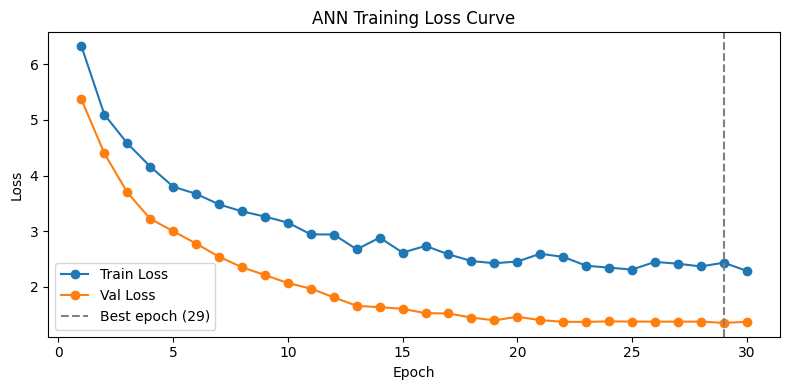

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# ── Model definition ───────────────────────────────────────────────
class TabularANN(nn.Module):
    def __init__(self, input_dim, num_classes=5, hidden=[128, 64], dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ── DataLoaders ────────────────────────────────────────────────────
def make_loader(X, y=None, batch_size=256, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    if y is not None:
        yt = torch.tensor(y.squeeze(), dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size)

tr_loader  = make_loader(X_tr,  y_tr,  shuffle=True)
val_loader = make_loader(X_val, y_val)

# ── Training ───────────────────────────────────────────────────────
EPOCHS  = 30

ann       = TabularANN(input_dim=X_tr.shape[1]).to(DEVICE)
optimizer = torch.optim.AdamW(ann.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = rww_loss_fn #nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_loss, best_state = float('inf'), None
train_losses, val_losses  = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    ann.train()
    train_loss = 0
    for Xb, yb in tr_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(ann(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(tr_loader)
    train_losses.append(train_loss)
    scheduler.step()

    # ── Validate ──
    ann.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            logits = ann(Xb.to(DEVICE))
            val_loss += criterion(logits, yb.to(DEVICE)).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    f1 = f1_score(trues, preds, average='macro')
    print(f'Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = ann.state_dict()

ann.load_state_dict(best_state)
print('Training complete. Best val loss:', round(best_val_loss, 4))

# ── Loss curve ─────────────────────────────────────────────────────
best_epoch = val_losses.index(best_val_loss) + 1

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS + 1), val_losses,   label='Val Loss',   marker='o')
plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ANN Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('ann_loss_curve.png', dpi=150)
plt.show()

# ── Get probabilities for fusion ───────────────────────────────────
def get_probs(model, X):
    model.eval()
    loader = make_loader(X)
    probs  = []
    with torch.no_grad():
        for (Xb,) in loader:
            logits = model(Xb.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(probs)

ann_val_probs  = get_probs(ann, X_val)
ann_test_probs = get_probs(ann, X_test)

## XGBoost Model Building (tabular)

Training complete. Best val loss: 0.3754
XGBoost-only Val Macro-F1: 0.8427
              precision    recall  f1-score   support

    Acuity 1       0.96      0.96      0.96        72
    Acuity 2       0.94      0.91      0.93        75
    Acuity 3       0.81      0.84      0.82        75
    Acuity 4       0.73      0.66      0.69        73
    Acuity 5       0.77      0.86      0.82        59

    accuracy                           0.84       354
   macro avg       0.84      0.85      0.84       354
weighted avg       0.84      0.84      0.84       354



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [18:07:56] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


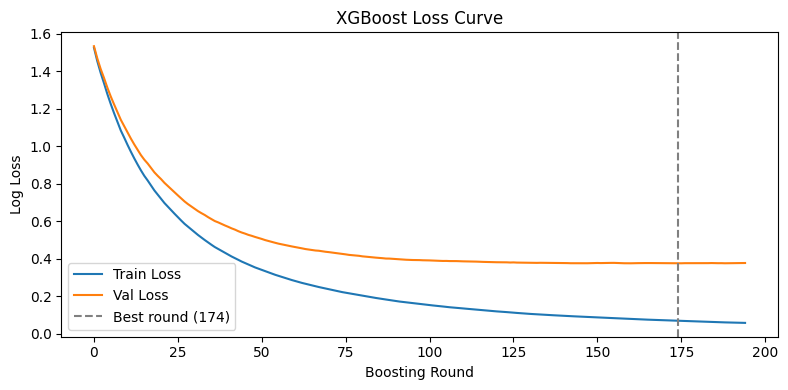

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# ----- Model definition & training -----
xgb_clf = xgb.XGBClassifier(
    objective = 'multi:softprob',  # outputs class probabilities
    num_class = 5,
    n_estimators = 500,
    max_depth = 6,
    learning_rate = 0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    reg_alpha = 0.1,               # L1 regularization
    reg_lambda = 1.0,               # L2 regularization
    eval_metric = 'mlogloss',
    early_stopping_rounds = 20,
    random_state = SEED,
    device = 'cuda' if torch.cuda.is_available() else 'cpu' # no support or MacOS
)

xgb_clf.fit(
    X_tr, y_tr,
    eval_set = [(X_tr, y_tr), (X_val, y_val)],
    verbose  = False
)

print('Training complete. Best val loss:',
      round(xgb_clf.best_score, 4))

# ----- DataLoaders -----
def make_loader(X, y=None, batch_size=256, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    if y is not None:
        yt = torch.tensor(y.squeeze(), dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size)


# ----- Evaluation -----
xgb_val_preds = xgb_clf.predict(X_val)
f1 = f1_score(y_val, xgb_val_preds, average='macro')
print(f'XGBoost-only Val Macro-F1: {f1:.4f}')
print(classification_report(y_val, xgb_val_preds,
                             target_names=[f'Acuity {i+1}' for i in range(5)]))



xgb_val_probs  = xgb_clf.predict_proba(X_val)       # (n_val,  5)
xgb_test_probs = xgb_clf.predict_proba(X_test)      # (n_test, 5)

# ----- Loss Curve -----
results = xgb_clf.evals_result()

plt.figure(figsize=(8, 4))
plt.plot(results['validation_0']['mlogloss'], label='Train Loss')
plt.plot(results['validation_1']['mlogloss'], label='Val Loss')
plt.axvline(xgb_clf.best_iteration, color='gray', linestyle='--',
            label=f'Best round ({xgb_clf.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_loss_curve.png', dpi=150)
plt.show()

## RNN Model Building (text)

In [14]:
from collections import Counter

MAX_VOCAB = 20000
MAX_LEN   = 10

def tokenize(text):
    return text.lower().split()

# Build vocab from augmented training data
counter = Counter()
for text in texts_tr_aug:
    counter.update(tokenize(text))

vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(MAX_VOCAB))}
vocab[''] = 0
vocab[''] = 1

def encode(text):
    tokens = tokenize(text)
    ids = [vocab.get(t, 1) for t in tokens][:MAX_LEN]
    if len(ids) < MAX_LEN:
        ids += [0] * (MAX_LEN - len(ids))
    return ids

X_text_tr  = np.array([encode(t) for t in texts_tr_aug])
X_text_val = np.array([encode(t) for t in texts_val])
X_text_test = np.array([encode(t) for t in texts_test])

Epoch 01 | Train Loss: 4.1444 | Val Loss: 1.8608 | Val F1: 0.0758
Epoch 02 | Train Loss: 2.0157 | Val Loss: 1.7143 | Val F1: 0.0739
Epoch 03 | Train Loss: 1.9148 | Val Loss: 1.8940 | Val F1: 0.0676
           | No improvement. Patience: 1/3
Epoch 04 | Train Loss: 1.8539 | Val Loss: 1.7076 | Val F1: 0.0840
Epoch 05 | Train Loss: 1.9727 | Val Loss: 1.9124 | Val F1: 0.0703
           | No improvement. Patience: 1/3
Epoch 06 | Train Loss: 1.8951 | Val Loss: 1.7608 | Val F1: 0.1138
           | No improvement. Patience: 2/3
Epoch 07 | Train Loss: 1.8490 | Val Loss: 1.6913 | Val F1: 0.1188
Epoch 08 | Train Loss: 1.8689 | Val Loss: 1.7030 | Val F1: 0.1184
           | No improvement. Patience: 1/3
Epoch 09 | Train Loss: 1.8035 | Val Loss: 1.6657 | Val F1: 0.0676
Epoch 10 | Train Loss: 1.8026 | Val Loss: 1.6696 | Val F1: 0.0908
           | No improvement. Patience: 1/3
Epoch 11 | Train Loss: 1.8241 | Val Loss: 1.9901 | Val F1: 0.1427
           | No improvement. Patience: 2/3
Epoch 12 | Train

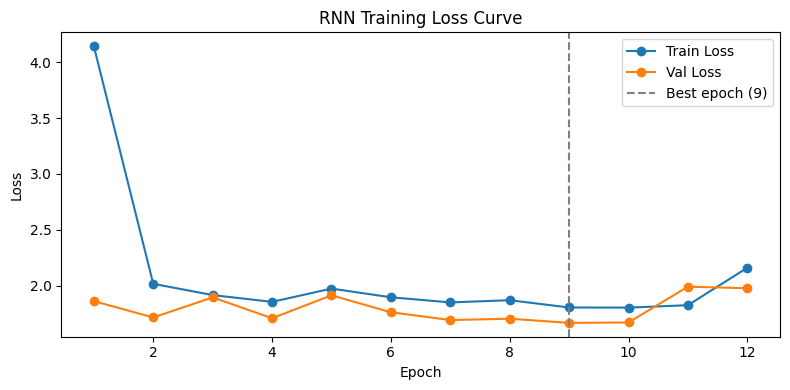

In [15]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_classes=5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size+1, embed_dim)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)                # this is the batch size, sequence length, and embedding size
        _, (h, _) = self.lstm(emb)             # this is final hidden state
        out = self.fc(self.dropout(h[-1]))     # this is the batch size and the number of levels in target variable
        return out, h[-1]                      # this is returning the embeddings for fusion

def make_text_loader(X, y=None, batch_size=128, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.long)
    if y is not None:
        yt = torch.tensor(y.squeeze(), dtype=torch.long)
        return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)
    return DataLoader(TensorDataset(Xt), batch_size=batch_size)

tr_text_loader  = make_text_loader(X_text_tr,  y_tr_aug, shuffle=True)
val_text_loader = make_text_loader(X_text_val, y_val)

import torch
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# ── Model, optimizer, loss ─────────────────────────────────────────
rnn       = RNNClassifier(vocab_size=len(vocab)).to(DEVICE)
optimizer = torch.optim.Adam(rnn.parameters(), lr=5e-4)
class_counts = np.bincount(y_tr_aug)
weights = 1.0 / class_counts
weights = weights / weights.sum()
criterion = rww_loss_fn #nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))

# ── Early stopping ─────────────────────────────────────────────────
max_epochs        = 50
patience          = 3
best_val_loss     = float('inf')
epochs_no_improve = 0
best_state        = None
train_losses      = []
val_losses        = []

for epoch in range(max_epochs):
    # ── Train ──
    rnn.train()
    total_loss = 0
    for Xb, yb in tr_text_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = rnn(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(tr_text_loader)
    train_losses.append(avg_train_loss)

    # ── Validate ──
    rnn.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in val_text_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits, _ = rnn(Xb)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.cpu().numpy())

    avg_val_loss = val_loss / len(val_text_loader)
    val_losses.append(avg_val_loss)
    f1 = f1_score(trues, preds, average='macro')
    print(f'Epoch {epoch+1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {f1:.4f}')

    # ── Early stopping ──
    if avg_val_loss < best_val_loss:
        best_val_loss     = avg_val_loss
        best_state        = rnn.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f'           | No improvement. Patience: {epochs_no_improve}/{patience}')
        if epochs_no_improve >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

rnn.load_state_dict(best_state)
print(f'Training complete. Best val loss: {best_val_loss:.4f}')

# ── Loss curve ─────────────────────────────────────────────────────
epochs_ran = range(1, len(train_losses) + 1)
best_epoch = val_losses.index(best_val_loss) + 1

plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_ran, val_losses,   label='Val Loss',   marker='o')
plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('rnn_loss_curve.png', dpi=150)
plt.show()

def get_rnn_outputs(model, X):
    model.eval()
    loader = make_text_loader(X)
    probs, embs = [], []
    with torch.no_grad():
        for (Xb,) in loader:
            logits, h = model(Xb.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            embs.append(h.cpu().numpy())
    return np.vstack(probs), np.vstack(embs)

X_text_tr_fusion  = np.array([encode(t) for t in texts_tr])
rnn_tr_probs,  rnn_tr_embs  = get_rnn_outputs(rnn, X_text_tr_fusion)
rnn_val_probs,  rnn_val_embs  = get_rnn_outputs(rnn, X_text_val)
rnn_test_probs, rnn_test_embs = get_rnn_outputs(rnn, X_text_test)

## ClinicalBERT Model Building (text)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 5.3485 | Val Loss: 4.5462 | Val Macro-F1: 0.3169
Epoch 02 | Train Loss: 4.4104 | Val Loss: 4.2616 | Val Macro-F1: 0.3296
Epoch 03 | Train Loss: 4.0560 | Val Loss: 4.0925 | Val Macro-F1: 0.4229
Epoch 04 | Train Loss: 3.5285 | Val Loss: 1.0370 | Val Macro-F1: 0.6995
Epoch 05 | Train Loss: 0.7460 | Val Loss: 0.5277 | Val Macro-F1: 0.8519
Epoch 06 | Train Loss: 0.4015 | Val Loss: 0.3642 | Val Macro-F1: 0.9419
Epoch 07 | Train Loss: 0.2150 | Val Loss: 0.2596 | Val Macro-F1: 0.9691
Epoch 08 | Train Loss: 0.2077 | Val Loss: 0.3321 | Val Macro-F1: 0.9554
           | No improvement. Patience: 1/3
Epoch 09 | Train Loss: 0.1389 | Val Loss: 0.2818 | Val Macro-F1: 0.9663
           | No improvement. Patience: 2/3
Epoch 10 | Train Loss: 0.1395 | Val Loss: 0.2677 | Val Macro-F1: 0.9664
           | No improvement. Patience: 3/3
Early stopping at epoch 10.
Training complete. Best val loss: 0.2596


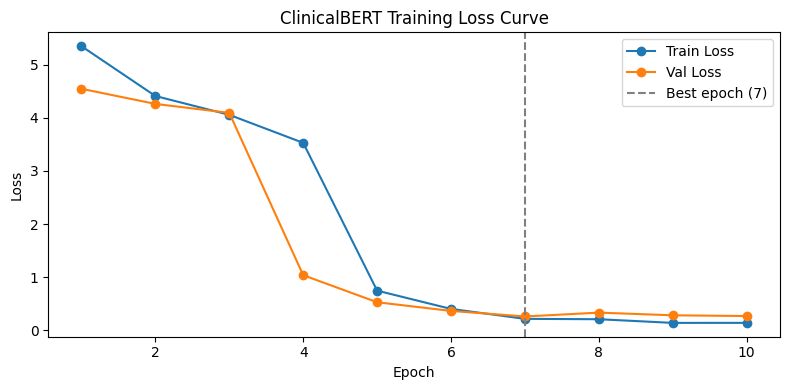

In [16]:
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

BERT_MODEL = 'emilyalsentzer/Bio_ClinicalBERT'
MAX_LEN    = 32

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# ── Dataset ────────────────────────────────────────────────────────
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels=None):
        self.texts  = list(texts)
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(self.texts[idx], max_length=MAX_LEN,
                        padding='max_length', truncation=True,
                        return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# ── Model ──────────────────────────────────────────────────────────
class ClinicalBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes=5, dropout=0.1):
        super().__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        hidden_size  = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.clf     = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        out     = self.bert(input_ids=input_ids,
                            attention_mask=attention_mask,
                            token_type_ids=token_type_ids)
        cls_emb = out.last_hidden_state[:, 0, :]
        logits  = self.clf(self.dropout(cls_emb))
        return logits, cls_emb

# ── DataLoaders ────────────────────────────────────────────────────
tr_text_ds  = TextDataset(texts_tr_aug, y_tr_aug.squeeze())
val_text_ds = TextDataset(texts_val, y_val.squeeze())

tr_text_loader  = DataLoader(tr_text_ds,  batch_size=64, shuffle=True)
val_text_loader = DataLoader(val_text_ds, batch_size=64)

# ── Training ───────────────────────────────────────────────────────
BERT_EPOCHS = 50
PATIENCE    = 3

bert_clf       = ClinicalBERTClassifier(BERT_MODEL).to(DEVICE)
bert_optimizer = torch.optim.AdamW(bert_clf.parameters(), lr=2e-5, weight_decay=1e-2)
class_counts = np.bincount(y_tr_aug)
weights = 1.0 / class_counts
weights = weights / weights.sum()
bert_criterion = rww_loss_fn #nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE))
bert_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(bert_optimizer, T_max=BERT_EPOCHS)

best_bert_loss  = float('inf')
best_bert_state = None
patience_count  = 0
train_losses    = []
val_losses      = []

for epoch in range(1, BERT_EPOCHS + 1):
    # ── Train ──
    bert_clf.train()
    epoch_train_loss = 0
    for batch in tr_text_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)

        bert_optimizer.zero_grad()
        logits, _ = bert_clf(input_ids, attn_mask)
        loss      = bert_criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_clf.parameters(), max_norm=1.0)
        bert_optimizer.step()
        epoch_train_loss += loss.item()

    epoch_train_loss /= len(tr_text_loader)
    train_losses.append(epoch_train_loss)
    bert_scheduler.step()  # epoch-level

    # ── Validate ──
    bert_clf.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for batch in val_text_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels    = batch['labels'].to(DEVICE)
            logits, _ = bert_clf(input_ids, attn_mask)
            val_loss += bert_criterion(logits, labels).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(labels.cpu().numpy())

    val_loss /= len(val_text_loader)
    val_losses.append(val_loss)
    f1 = f1_score(trues, preds, average='macro')
    print(f'Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

    # ── Early stopping ──
    if val_loss < best_bert_loss:
        best_bert_loss  = val_loss
        best_bert_state = bert_clf.state_dict()
        patience_count  = 0
    else:
        patience_count += 1
        print(f'           | No improvement. Patience: {patience_count}/{PATIENCE}')
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

bert_clf.load_state_dict(best_bert_state)
print('Training complete. Best val loss:', round(best_bert_loss, 4))

# ── Loss curve ─────────────────────────────────────────────────────
epochs_ran = range(1, len(train_losses) + 1)
best_epoch = val_losses.index(best_bert_loss) + 1

plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, train_losses, label='Train Loss', marker='o')
plt.plot(epochs_ran, val_losses,   label='Val Loss',   marker='o')
plt.axvline(best_epoch, color='gray', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ClinicalBERT Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('bert_loss_curve.png', dpi=150)
plt.show()

# ── Get probabilities and embeddings for fusion ────────────────────
def get_bert_probs_and_embeddings(model, texts, labels=None):
    model.eval()
    ds     = TextDataset(texts, labels)
    loader = DataLoader(ds, batch_size=32)
    probs, embeddings = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            logits, cls_emb = model(input_ids, attn_mask)
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
            embeddings.append(cls_emb.cpu().numpy())
    return np.vstack(probs), np.vstack(embeddings)

bert_val_probs,  bert_val_embs  = get_bert_probs_and_embeddings(bert_clf, texts_val)
bert_test_probs, bert_test_embs = get_bert_probs_and_embeddings(bert_clf, texts_test)

## Evaluation of Individual Models

In [17]:
print('=' * 38)
print(f'{"Model":<20} {"Macro-F1":>10}')
print('=' * 38)

for name, probs in [('ANN (tabular)', ann_test_probs),
                    ('XGBoost (tabular)', xgb_test_probs),
                    ('RNN (text)', rnn_test_probs),
                    ('ClinicalBERT (text)', bert_test_probs)]:
    preds = probs.argmax(axis=1)
    f1    = f1_score(y_test.squeeze(), preds, average='macro')
    print(f'{name:<20} {f1:>10.4f}')

print('=' * 38)

Model                  Macro-F1
ANN (tabular)            0.5004
XGBoost (tabular)        0.8440
RNN (text)               0.1067
ClinicalBERT (text)      0.9545


## Fusion: XGBoost + ClinicalBERT

In [18]:
class EarlyFusionHead(nn.Module):
    def __init__(self, input_dim, num_classes=5, hidden=[256, 128], dropout=0.3):
        super().__init__()
        layers = []
        in_d = input_dim
        for h in hidden:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

cost_matrix = np.array([[0, 1, 2, 3, 4],
                         [1, 0, 1, 2, 3],
                         [2, 1, 0, 1, 2],
                         [3, 2, 1, 0, 1],
                         [4, 3, 2, 1, 0]])

def cost_sensitive_score(y_true, y_pred, cost_matrix):
    total_cost = sum(cost_matrix[t][p] for t, p in zip(y_true, y_pred))
    # normalize by worst possible cost
    worst_cost = sum(cost_matrix[t].max() for t in y_true)
    return 1 - (total_cost / worst_cost)  # higher is better

import matplotlib.ticker as ticker
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
CLASS_NAMES = ['Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']

Epoch 01 | Train Loss: 3.0689 | Val Loss: 0.5778 | Val Macro-F1: 0.8785
Epoch 02 | Train Loss: 0.3895 | Val Loss: 0.2779 | Val Macro-F1: 0.9609
Epoch 03 | Train Loss: 0.2217 | Val Loss: 0.2257 | Val Macro-F1: 0.9717
Epoch 04 | Train Loss: 0.1608 | Val Loss: 0.2485 | Val Macro-F1: 0.9744
Epoch 05 | Train Loss: 0.1510 | Val Loss: 0.2969 | Val Macro-F1: 0.9744
Epoch 06 | Train Loss: 0.1868 | Val Loss: 0.2957 | Val Macro-F1: 0.9744
Epoch 07 | Train Loss: 0.1599 | Val Loss: 0.2939 | Val Macro-F1: 0.9717
Epoch 08 | Train Loss: 0.1665 | Val Loss: 0.2934 | Val Macro-F1: 0.9717
Epoch 09 | Train Loss: 0.1249 | Val Loss: 0.2968 | Val Macro-F1: 0.9717
Epoch 10 | Train Loss: 0.1940 | Val Loss: 0.3024 | Val Macro-F1: 0.9717
Epoch 11 | Train Loss: 0.2159 | Val Loss: 0.2944 | Val Macro-F1: 0.9717
Epoch 12 | Train Loss: 0.1593 | Val Loss: 0.2932 | Val Macro-F1: 0.9717
Epoch 13 | Train Loss: 0.1814 | Val Loss: 0.2486 | Val Macro-F1: 0.9717
Epoch 14 | Train Loss: 0.1779 | Val Loss: 0.2453 | Val Macro-F1:

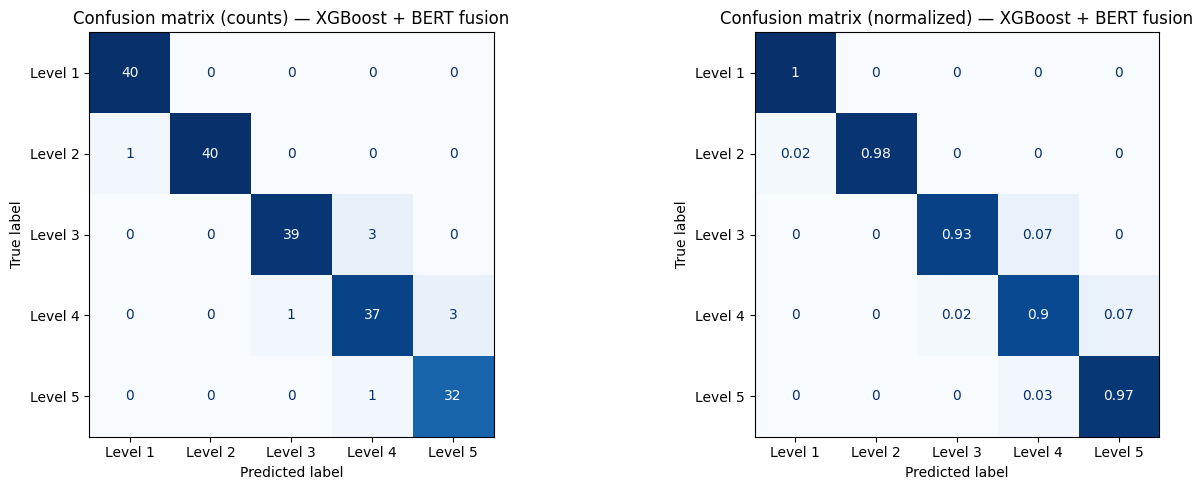

In [19]:
# ── Late fusion: XGBoost + BERT ────────────────────────────────────
late_val_probs_bert  = (xgb_val_probs + bert_val_probs) / 2
late_test_probs_bert = (xgb_test_probs + bert_test_probs) / 2

late_val_preds_bert  = late_val_probs_bert.argmax(axis=1)
late_test_preds_bert = late_test_probs_bert.argmax(axis=1)

# ── Early fusion ───────────────────────────────────────────────────
bert_tr_probs, bert_tr_embs = get_bert_probs_and_embeddings(bert_clf, texts_tr)

early_tr_X_bert   = np.concatenate([bert_tr_embs, X_tr],  axis=1)
early_val_X_bert  = np.concatenate([bert_val_embs, X_val], axis=1)
early_test_X_bert = np.concatenate([bert_test_embs, X_test], axis=1)

INPUT_DIM_BERT = early_tr_X_bert.shape[1]

fusion_head_bert = EarlyFusionHead(input_dim=INPUT_DIM_BERT).to(DEVICE)

ef_tr_loader_bert  = make_loader(early_tr_X_bert,  y_tr,  shuffle=True)
ef_val_loader_bert = make_loader(early_val_X_bert, y_val)

# ── Train early fusion head ────────────────────────────────────────
EPOCHS_EF_BERT = 20
optimizer_ef_bert = torch.optim.AdamW(fusion_head_bert.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_ef_bert = rww_loss_fn # nn.CrossEntropyLoss()
scheduler_ef_bert = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ef_bert, T_max=EPOCHS_EF_BERT)

best_val_loss_ef_bert, best_state_ef_bert = float('inf'), None

for epoch in range(1, EPOCHS_EF_BERT + 1):
    fusion_head_bert.train()
    train_loss = 0
    for Xb, yb in ef_tr_loader_bert:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer_ef_bert.zero_grad()
        loss = criterion_ef_bert(fusion_head_bert(Xb), yb)
        loss.backward()
        optimizer_ef_bert.step()
        train_loss += loss.item()
    scheduler_ef_bert.step()

    train_loss /= len(ef_tr_loader_bert)

    # Validation
    fusion_head_bert.eval()
    val_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for Xb, yb in ef_val_loader_bert:
            logits = fusion_head_bert(Xb.to(DEVICE))
            val_loss += criterion_ef_bert(logits, yb.to(DEVICE)).item()
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())

    val_loss /= len(ef_val_loader_bert)
    f1 = f1_score(trues, preds, average='macro')
    print(f'Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Macro-F1: {f1:.4f}')

    if val_loss < best_val_loss_ef_bert:
        best_val_loss_ef_bert = val_loss
        best_state_ef_bert    = fusion_head_bert.state_dict()

fusion_head_bert.load_state_dict(best_state_ef_bert)
print('Best val loss:', round(best_val_loss_ef_bert, 4))

# ── Early fusion predictions ───────────────────────────────────────
ef_val_preds_bert  = fusion_head_bert(torch.tensor(early_val_X_bert,  dtype=torch.float32).to(DEVICE))
ef_test_preds_bert = fusion_head_bert(torch.tensor(early_test_X_bert, dtype=torch.float32).to(DEVICE))

ef_val_preds_bert  = ef_val_preds_bert.argmax(1).cpu().numpy()
ef_test_preds_bert = ef_test_preds_bert.argmax(1).cpu().numpy()

# ── Results ────────────────────────────────────────────────────────
print('\nResults across models on test set')
for name, p in [('XGBoost only',  xgb_test_probs.argmax(1)),
                ('BERT only',     bert_test_probs.argmax(1)),
                ('Late Fusion',   late_test_preds_bert),
                ('Early Fusion',  ef_test_preds_bert)]:
    f1 = f1_score(y_test.squeeze(), p, average='macro')
    print(f'{name:<20} Macro-F1: {f1:.4f}')

# ── Cost-sensitive score ───────────────────────────────────────────
score = cost_sensitive_score(y_test.squeeze(), late_test_preds_bert, cost_matrix)
print(f'\nCost-sensitive score (late fusion): {score:.4f}')

# ── Confusion matrix ───────────────────────────────────────────────
cm      = confusion_matrix(y_test, ef_test_preds_bert)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (counts) — XGBoost + BERT fusion')

disp_norm = ConfusionMatrixDisplay(np.round(cm_norm, 2), display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion matrix (normalized) — XGBoost + BERT fusion')

plt.tight_layout()
plt.savefig('confusion_matrix_xgb_bert_fusion.png', dpi=150)
plt.show()